1. Libraritë u importuan me sukses!

2. Dataseti u ngarkua!
Dimensionet fillestare: 25000 rreshta dhe 13 kolona.
Kolonat e panevojshme u hoqën dhe vlerat boshe u pastruan.
Kodimi numerik i të dhënave përfundoi med sukses. Pamja e parë e të dhënave të reja:
   gender  age_group  region  product_category  purchase_channel  platform  \
0       1          4       2                 0                 0         6   
1       2          3       0                 2                 0        17   
2       0          2       1                 7                 0         5   
3       0          0       0                 5                 0        19   
4       0          0       1                 3                 0         4   

   customer_rating  sentiment  response_time_hours  issue_resolved  \
0                1          0                   46               1   
1                5          2                    5               1   
2                1          0                   38              

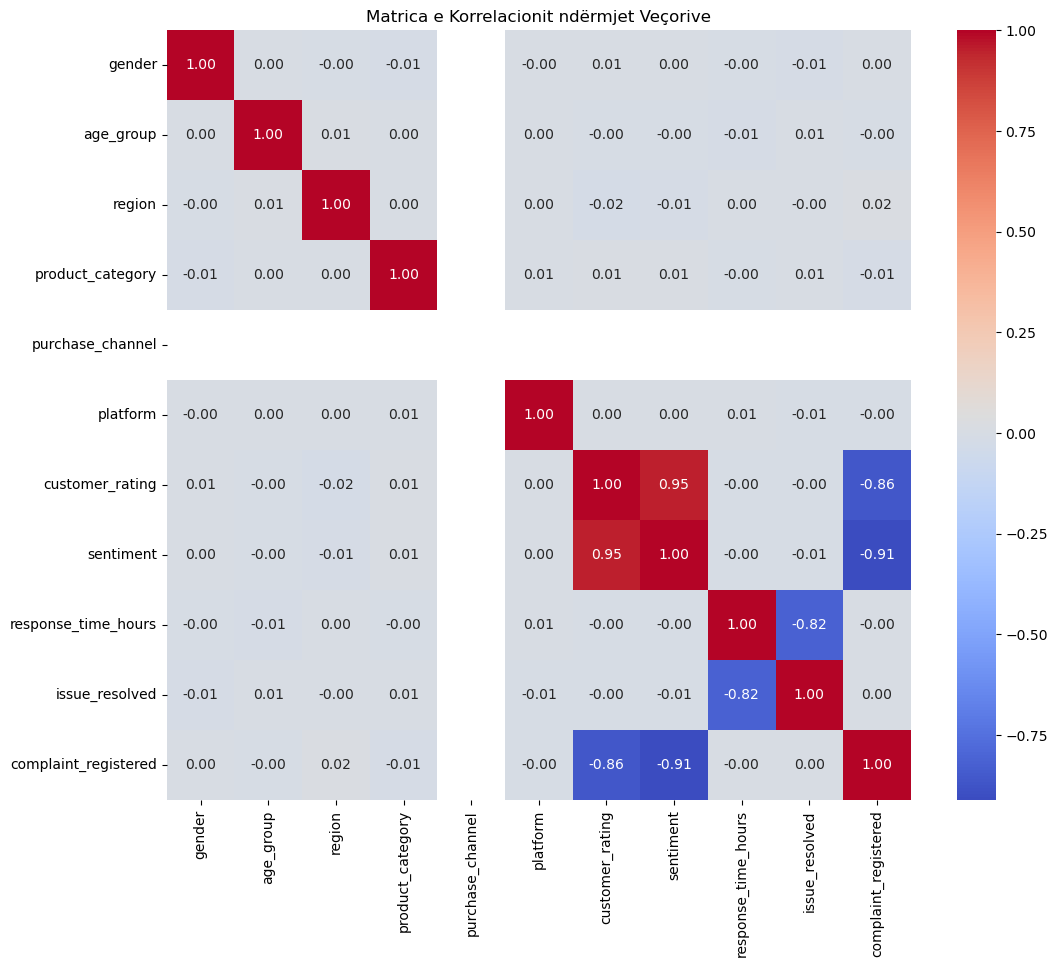


Ndarja përfundoi: Train set = 20000 rreshta, Test set = 5000 rreshta.

Duke trajnuar KNN dhe duke kërkuar hiperparametrat optimalë...
Hiperparametrat më të mirë për KNN: {'metric': 'manhattan', 'n_neighbors': 11}

Duke trajnuar Logistic Regression dhe duke kërkuar hiperparametrat optimalë...
Hiperparametrat më të mirë për Logistic Regression: {'C': 0.1}

 METRIKAT PËR MODELIN: K-NEAREST NEIGHBORS (KNN)
Accuracy (Saktësia):  0.9990
Precision:            0.9990
Recall:               0.9990
F1-Score:             0.9990

Matrica e Konfuzionit:
[[1997    0    0]
 [   0 1017    4]
 [   0    1 1981]]

 METRIKAT PËR MODELIN: LOGISTIC REGRESSION
Accuracy (Saktësia):  1.0000
Precision:            1.0000
Recall:               1.0000
F1-Score:             1.0000

Matrica e Konfuzionit:
[[1997    0    0]
 [   0 1021    0]
 [   0    0 1982]]


TABELA KRAHASUESE E PJESËS SË PARË:
                   Modeli  Accuracy  Precision  Recall  F1-Score
K-Nearest Neighbors (KNN)     0.999   0.999001   0.999  

In [ ]:
# =====================================================================
# PROJEKTI: MACHINE LEARNING MODELS
# PJESA 1: PARAPËRPUNIMI I TË DHËNAVE DHE KLASIFIKUESIT E PARË (KNN & LOGISTIC REGRESSION)
# =====================================================================

# --- HAPI 1: IMPORTIMI I LIBRARIVE TË NEVOJSHME ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

print("1. Libraritë u importuan me sukses!")

# --- HAPI 2: NGARKIMI DHE SHIKIMI INITIAL I TË DHËNAVE ---

df = pd.read_csv('Customer_Sentiment.csv')

print("\n2. Dataseti u ngarkua!")
print(f"Dimensionet fillestare: {df.shape[0]} rreshta dhe {df.shape[1]} kolona.")

# --- HAPI 3: PARAPËRPUNIMI DHE PASTRIMI I TË DHËNAVE ---

df_cleaned = df.drop(columns=['customer_id', 'review_text'])

# Fshirja e rreshtave që eventualisht kanë vlera boshe (Missing Values)
df_cleaned = df_cleaned.dropna()
print("Kolonat e panevojshme u hoqën dhe vlerat boshe u pastruan.")

# --- HAPI 4: KODIMI I VARIABLAVE KATEGORIALE (LABEL ENCODING) ---

le = LabelEncoder()

categorical_cols = [
    'gender', 'age_group', 'region', 'product_category', 
    'purchase_channel', 'platform', 'issue_resolved', 'complaint_registered'
]

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# Kodojmë edhe variablën synuese (Target) që është 'sentiment'

df_cleaned['sentiment'] = le.fit_transform(df_cleaned['sentiment'])

print("Kodimi numerik i të dhënave përfundoi med sukses. Pamja e parë e të dhënave të reja:")
print(df_cleaned.head())

# --- HAPI 5: EKSPERIMENTIMI ME VEÇORITË (MATRICA E KORRELACIONIT) ---

plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrica e Korrelacionit ndërmjet Veçorive")
plt.show()

# --- HAPI 6: NDARJA TRAIN / TEST DHE SHKALLËZIMI (SCALING) ---

X = df_cleaned.drop(columns=['sentiment'])
y = df_cleaned['sentiment']

# Ndarja në 80% Trajnim dhe 20% Testim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shkallëzimi me StandardScaler (Kritik për KNN dhe modelet lineare)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nNdarja përfundoi: Train set = {X_train.shape[0]} rreshta, Test set = {X_test.shape[0]} rreshta.")

# --- HAPI 7: MODELI 1 - K-NEAREST NEIGHBORS (KNN) ME GRIDSEARCHCV ---
print("\nDuke trajnuar KNN dhe duke kërkuar hiperparametrat optimalë...")
knn_params = {
    'n_neighbors': [3, 5, 11], 
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
print(f"Hiperparametrat më të mirë për KNN: {grid_knn.best_params_}")

# --- HAPI 8: MODELI 2 - LOGISTIC REGRESSION (LINEAR) ME GRIDSEARCHCV ---
print("\nDuke trajnuar Logistic Regression dhe duke kërkuar hiperparametrat optimalë...")
log_params = {
    'C': [0.1, 1, 10]
}

grid_log = GridSearchCV(LogisticRegression(max_iter=1000), log_params, cv=3, scoring='accuracy')
grid_log.fit(X_train_scaled, y_train)

best_log = grid_log.best_estimator_
y_pred_log = best_log.predict(X_test_scaled)
print(f"Hiperparametrat më të mirë për Logistic Regression: {grid_log.best_params_}")

# --- HAPI 9: VLERËSIMI I MODELEVE (METRIKAT E KËRKUARA) ---
def kalkulo_metrikat(y_true, y_pred, emri_modelit):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n==========================================")
    print(f" METRIKAT PËR MODELIN: {emri_modelit.upper()}")
    print(f"==========================================")
    print(f"Accuracy (Saktësia):  {acc:.4f}")
    print(f"Precision:            {prec:.4f}")
    print(f"Recall:               {rec:.4f}")
    print(f"F1-Score:             {f1:.4f}")
    print("\nMatrica e Konfuzionit:")
    print(cm)
    return [emri_modelit, acc, prec, rec, f1]

# Ekzekutimi i vlerësimeve
rezultatet_knn = kalkulo_metrikat(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")
rezultatet_log = kalkulo_metrikat(y_test, y_pred_log, "Logistic Regression")

# Krijimi i një tabele të përkohshme për pjesën tënde
tabela_pjesa1 = pd.DataFrame(
    [rezultatet_knn, rezultatet_log], 
    columns=['Modeli', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)
print("\n\nTABELA KRAHASUESE E PJESËS SË PARË:")
print(tabela_pjesa1.to_string(index=False))
